# 04-1 로지스틱 회귀
- 생선이 랜덤으로 들어있는 럭키백
- 럭키백에 들어갈 수 있는 생선은 7개
- 생선의 크기, 무게 등이 주어졌을 때 7개 생선에 대한 확률은?
- target: 생선 종류
- feature: 무게, 길이, 대각선, 높이, 두께

In [4]:
# 판다스로 데이터 준비
import pandas as pd

fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
# 어떤 종류의 생선이 있는지 확인
print(pd.unique(fish['Species']))

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str


In [6]:
# 무게, 길이, 대각선, 높이, 두께를 input data로 설정
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
# fish_input 확인
fish_input.head()

,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [7]:
# 타겟 데이터
fish_target = fish['Species']

# 훈련 세트와 테스트 세트 나누기
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

# 표준화
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

## k-최근접 이웃 분류기의 확률 예측
- k = 3

In [8]:
# k-최근접 이웃 분류기 훈련
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target)) # 훈련 점수
print(kn.score(test_scaled, test_target))   # 테스트 점수

0.8907563025210085
0.85


In [11]:
# 타깃값 순서 확인
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [9]:
# 처음 5개 샘플 테스트
kn.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype=object)

In [10]:
# 클래스 별 확률 확인
import numpy as np
proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=4)) # 소수점 다섯 번째 자리에서 반올림

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [12]:
# 네 번째 샘플의 가장 가까운 이웃 확인
distance, indexes = kn.kneighbors(test_scaled[3:4]) # indexes = 샘플 번호
print(train_target.iloc[indexes[0]]) 

52     Roach
106    Perch
103    Perch
Name: Species, dtype: str


## 로지스틱 회귀

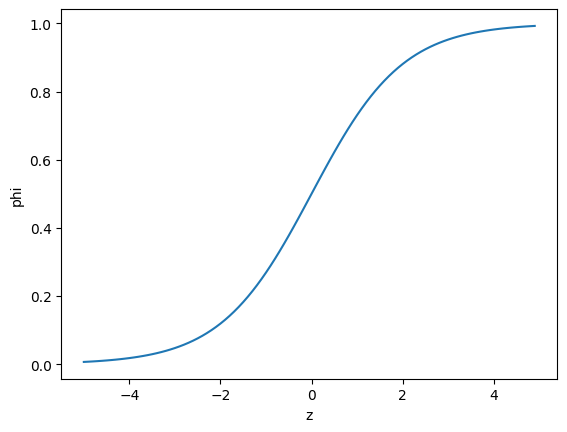

In [13]:
# sigmoid 함수 그래프 확인
import numpy as np
import matplotlib.pyplot as plt

z = np.arange(-5, 5, 0.1)
phi = 1 / (1 + np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

### 로지스틱 회귀로 도미와 빙어 이진 분류

In [14]:
# 훈련 세트에서 도미(Bream)와 빙어(Smelt)만 골라내기
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')  # 도미와 빙어이면 1, 외에는 0
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

In [15]:
# 로지스틱 회귀 모델 훈련
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

# 처음 5개 샘플 예측
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [ ]:
# 예측 확률(bream이 0, smelt가 1)
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [18]:
# 로지스틱 회귀 모델이 학습한 계수 확인
print(lr.coef_, lr.intercept_)

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]


In [ ]:
# 처음 5개 샘플의 z값 출력
decision = lr.decision_function(train_bream_smelt[:5]) # 양성 클래스의 z값 반환
print(decision) # 이 값을 시그모이드 함수에 통과시키면 확률을 알 수 있음

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [22]:
# z값을 시그모이드에 통과
from scipy.special import expit
print(expit(decision))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


## 로지스틱 회귀로 다중 분류 수행하기

In [24]:
lr = LogisticRegression(C=20, max_iter=1000) # C = 규제 제어 매개변수, 작을 수록 규제가 커짐
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

# 처음 5개 샘플에 대해 예측
print(lr.predict(test_scaled[:5]))

0.9327731092436975
0.925
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [26]:
# 처음 5개 샘플에 대한 예측 확률 출력
proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

# class 정보 출력
print(lr.classes_)

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


$Z = WX + b$
<br> $X$의 shape: (5, 샘플 개수)        
$W$의 shape: (7, 5)        *\*feature 개수 = 5*
<br> $Z$의 shape: (7, 샘플 개수)  *\*class 개수 = 7*